In [1]:
!pip install -q rasterio shapely geopandas segmentation-models-pytorch albumentations

import os, glob, random, json
import numpy as np
import cv2
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape, mapping

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.9 MB/s eta 0:00:00
cuda


In [2]:
DATA_ROOT = "/kaggle/input/datasets/hemuvenkat/oil-spill-sentinel-1-sar-images"
print("Image categories:", os.listdir(f"{DATA_ROOT}/Images"))
print("Mask categories:", os.listdir(f"{DATA_ROOT}/Mask"))

Image categories: ['Lookalike', 'No oil', 'Oil']
Mask categories: ['Lookalike', 'No oil', 'Oil']


In [3]:
def get_pairs(category):
    img_dir = f"{DATA_ROOT}/Images/{category}"
    mask_dir = f"{DATA_ROOT}/Mask/{category}"
    
    imgs = sorted(glob.glob(f"{img_dir}/*.tif"))
    masks = sorted(glob.glob(f"{mask_dir}/*.tif"))
    
    img_dict = {os.path.basename(f).split(".")[0]: f for f in imgs}
    mask_dict = {os.path.basename(f).split("_segmentation")[0]: f for f in masks}
    
    common_keys = sorted(set(img_dict.keys()) & set(mask_dict.keys()))
    paired_imgs = [img_dict[k] for k in common_keys]
    paired_masks = [mask_dict[k] for k in common_keys]
    
    print(f"{category}: {len(paired_imgs)} matched pairs")
    return paired_imgs, paired_masks

oil_imgs, oil_masks = get_pairs("Oil")
nooil_imgs, nooil_masks = get_pairs("No oil")
lookalike_imgs, lookalike_masks = get_pairs("Lookalike")

all_imgs = oil_imgs + nooil_imgs + lookalike_imgs
all_masks = oil_masks + nooil_masks + lookalike_masks
print(f"\nTotal combined: {len(all_imgs)}")

Oil: 150 matched pairs
No oil: 150 matched pairs
Lookalike: 150 matched pairs

Total combined: 450


In [4]:
from sklearn.model_selection import train_test_split

train_imgs, val_imgs, train_masks, val_masks = train_test_split(
    all_imgs, all_masks, test_size=0.15, random_state=SEED
)
print(f"Train: {len(train_imgs)} | Val: {len(val_imgs)}")

Train: 382 | Val: 68


In [5]:
IMG_SIZE = 512

train_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    ToTensorV2(),
])
val_transform = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    ToTensorV2(),
])

class SARGeoTiffDataset(Dataset):
    def __init__(self, img_paths, mask_paths, transform=None):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.transform = transform

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        with rasterio.open(self.img_paths[idx]) as src:
            vv = src.read(1)
            vh = src.read(2)

        def norm_band(b):
            b = np.clip(b, -35, 5)
            return ((b + 35) / 40 * 255).astype(np.uint8)

        vv_n = norm_band(vv)
        vh_n = norm_band(vh)
        avg_n = ((vv_n.astype(np.float32) + vh_n.astype(np.float32)) / 2).astype(np.uint8)
        img = np.stack([vv_n, vh_n, avg_n], axis=-1)

        with rasterio.open(self.mask_paths[idx]) as src:
            mask = src.read(1)
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img, mask = augmented["image"], augmented["mask"]

        img = img.float() / 255.0
        return img, mask.unsqueeze(0).float()

In [6]:
model = smp.DeepLabV3Plus(
    encoder_name="mobilenet_v2",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None,
).to(device)

dice_loss_fn = smp.losses.DiceLoss(mode="binary")
bce_loss_fn = nn.BCEWithLogitsLoss()

def combined_loss(pred, target):
    return 0.2 * dice_loss_fn(pred, target) + 0.8 * bce_loss_fn(pred, target)

def iou_score(pred, target, threshold=0.5, eps=1e-7):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) - intersection
    return ((intersection + eps) / (union + eps)).mean().item()

def dice_coef(pred, target, threshold=0.5, eps=1e-7):
    pred = (torch.sigmoid(pred) > threshold).float()
    intersection = (pred * target).sum(dim=(1,2,3))
    dice = (2*intersection + eps) / (pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + eps)
    return dice.mean().item()

print(sum(p.numel() for p in model.parameters() if p.requires_grad), "trainable parameters")

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/14.2M [00:00<?, ?B/s]

4378513 trainable parameters


In [7]:
train_ds = SARGeoTiffDataset(train_imgs, train_masks, transform=train_transform)
val_ds = SARGeoTiffDataset(val_imgs, val_masks, transform=val_transform)

BATCH_SIZE = 8
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

EPOCHS = 25
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=3)

best_val_loss = float("inf")
history = {"train_loss": [], "val_loss": [], "val_iou": [], "val_dice": []}

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = combined_loss(preds, masks)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * imgs.size(0)
    train_loss /= len(train_ds)

    model.eval()
    val_loss, val_iou, val_dice = 0.0, 0.0, 0.0
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(device), masks.to(device)
            preds = model(imgs)
            loss = combined_loss(preds, masks)
            val_loss += loss.item() * imgs.size(0)
            val_iou += iou_score(preds, masks) * imgs.size(0)
            val_dice += dice_coef(preds, masks) * imgs.size(0)
    val_loss /= len(val_ds)
    val_iou /= len(val_ds)
    val_dice /= len(val_ds)

    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_IoU: {val_iou:.4f} | val_Dice: {val_dice:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/kaggle/working/best_deeplabv3plus_mobilenet.pth")
        print("  -> saved new best model")

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 1/25 | train_loss: 0.5332 | val_loss: 0.5884 | val_IoU: 0.4130 | val_Dice: 0.4634
  -> saved new best model


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 2/25 | train_loss: 0.3822 | val_loss: 0.4286 | val_IoU: 0.5626 | val_Dice: 0.6070
  -> saved new best model


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

...

Epoch 23/25 | train_loss: 0.0737 | val_loss: 0.1347 | val_IoU: 0.7906 | val_Dice: 0.8292


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 24/25 | train_loss: 0.0968 | val_loss: 0.1024 | val_IoU: 0.7656 | val_Dice: 0.8043


/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset =

Epoch 25/25 | train_loss: 0.0799 | val_loss: 0.0877 | val_IoU: 0.7954 | val_Dice: 0.8334
  -> saved new best model


In [8]:
model.load_state_dict(torch.load("/kaggle/working/best_deeplabv3plus_mobilenet.pth"))
model.eval()

final_iou, final_dice = 0.0, 0.0
with torch.no_grad():
    for imgs, masks in val_loader:
        imgs, masks = imgs.to(device), masks.to(device)
        preds = model(imgs)
        final_iou += iou_score(preds, masks) * imgs.size(0)
        final_dice += dice_coef(preds, masks) * imgs.size(0)

final_iou /= len(val_ds)
final_dice /= len(val_ds)
print(f"Best model — Val IoU: {final_iou:.4f} | Val Dice: {final_dice:.4f}")

/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)
/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


Best model — Val IoU: 0.7954 | Val Dice: 0.8334


In [9]:
def mask_to_geojson(pred_mask_at_original_res, original_tiff_path, output_path="detection.geojson"):
    with rasterio.open(original_tiff_path) as src:
        transform = src.transform
        crs = src.crs

    features = []
    for geom, value in shapes(pred_mask_at_original_res.astype(np.int16),
                                mask=(pred_mask_at_original_res > 0),
                                transform=transform):
        if value == 1:
            polygon = shape(geom)
            centroid = polygon.centroid
            features.append({
                "type": "Feature",
                "geometry": mapping(polygon),
                "properties": {
                    "area": polygon.area,
                    "centroid_lon": centroid.x,
                    "centroid_lat": centroid.y,
                    "perimeter": polygon.length,
                }
            })

    fc = {
        "type": "FeatureCollection",
        "crs": {"type": "name", "properties": {"name": str(crs)}},
        "features": features,
    }
    with open(output_path, "w") as f:
        json.dump(fc, f, indent=2)
    print(f"Saved {len(features)} slick(s) to {output_path}")
    return fc

In [10]:
def run_full_pipeline(tiff_path, output_geojson="/kaggle/working/result.geojson"):
    with rasterio.open(tiff_path) as src:
        vv = src.read(1)
        vh = src.read(2)
        original_shape = vv.shape

    def norm_band(b):
        b = np.clip(b, -35, 5)
        return ((b + 35) / 40 * 255).astype(np.uint8)

    vv_n, vh_n = norm_band(vv), norm_band(vh)
    avg_n = ((vv_n.astype(np.float32) + vh_n.astype(np.float32)) / 2).astype(np.uint8)
    img_rgb = np.stack([vv_n, vh_n, avg_n], axis=-1)

    transformed = val_transform(image=img_rgb, mask=np.zeros(img_rgb.shape[:2]))
    input_tensor = (transformed["image"].float() / 255.0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(input_tensor))
        pred_mask = (pred > 0.5).float()[0, 0].cpu().numpy()

    pred_mask_full = cv2.resize(pred_mask, (original_shape[1], original_shape[0]), interpolation=cv2.INTER_NEAREST)

    return mask_to_geojson(pred_mask_full, tiff_path, output_geojson)

# Test on a real Oil-category image
result = run_full_pipeline(oil_imgs[0])
print(json.dumps(result, indent=2)[:1000])

Saved 18 slick(s) to /kaggle/working/result.geojson
{
  "type": "FeatureCollection",
  "crs": {
    "type": "name",
    "properties": {
      "name": "EPSG:4326"
    }
  },
  "features": [
    {
      "type": "Feature",
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [
              34.838979739693826,
              35.62018856223775
            ],
            [
              34.838979739693826,
              35.619110583896806
            ],
            [
              34.83933906580747,
              35.619110583896806
            ],
            [
              34.83933906580747,
              35.61946991001046
            ],
            [
              34.839698391921125,
              35.61946991001046
            ],
            [
              34.839698391921125,
              35.619829236124104
            ],
            [
              34.83933906580747,
              35.619829236124104
            ],
            [
              34

In [11]:
with open("/kaggle/working/result.geojson") as f:
    print(f.read())

{
  "type": "FeatureCollection",
  "crs": {
    "type": "name",
    "properties": {
      "name": "EPSG:4326"
    }
  },
  "features": [
    {
      "type": "Feature",
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [
              34.838979739693826,
              35.62018856223775
            ],
            [
              34.838979739693826,
              35.619110583896806
            ],
            [
              34.83933906580747,
              35.619110583896806
            ],
            [
              34.83933906580747,
              35.61946991001046
            ],
            [
              34.839698391921125,
              35.61946991001046
            ],
            [
              34.839698391921125,
              35.619829236124104
            ],
            [
              34.83933906580747,
              35.619829236124104
            ],
            [
              34.83933906580747,
              35.62018856223775
   

In [12]:
!pip install -q requests
import requests

with open("/kaggle/working/result.geojson") as f:
    content = f.read()

# Just print it in a way that's easy to select+copy in full
print(content)

{
  "type": "FeatureCollection",
  "crs": {
    "type": "name",
    "properties": {
      "name": "EPSG:4326"
    }
  },
  "features": [
    {
      "type": "Feature",
      "geometry": {
        "type": "Polygon",
        "coordinates": [
          [
            [
              34.838979739693826,
              35.62018856223775
            ],
            [
              34.838979739693826,
              35.619110583896806
            ],
            [
              34.83933906580747,
              35.619110583896806
            ],
            [
              34.83933906580747,
              35.61946991001046
            ],
            [
              34.839698391921125,
              35.61946991001046
            ],
            [
              34.839698391921125,
              35.619829236124104
            ],
            [
              34.83933906580747,
              35.619829236124104
            ],
            [
              34.83933906580747,
              35.62018856223775
   

In [13]:
import matplotlib.pyplot as plt
import base64
from IPython.display import HTML, display

def predict(image_path, save_folder="/kaggle/working/predictions"):
    os.makedirs(save_folder, exist_ok=True)
    filename = os.path.basename(image_path).replace(".tif", "")
    output_geojson = f"{save_folder}/{filename}_detection.geojson"

    with rasterio.open(image_path) as src:
        vv = src.read(1)
        vh = src.read(2)
        original_shape = vv.shape

    def norm_band(b):
        b = np.clip(b, -35, 5)
        return ((b + 35) / 40 * 255).astype(np.uint8)

    vv_n, vh_n = norm_band(vv), norm_band(vh)
    avg_n = ((vv_n.astype(np.float32) + vh_n.astype(np.float32)) / 2).astype(np.uint8)
    img_rgb = np.stack([vv_n, vh_n, avg_n], axis=-1)

    transformed = val_transform(image=img_rgb, mask=np.zeros(img_rgb.shape[:2]))
    input_tensor = (transformed["image"].float() / 255.0).unsqueeze(0).to(device)

    model.eval()
    with torch.no_grad():
        pred = torch.sigmoid(model(input_tensor))
        pred_mask = (pred > 0.5).float()[0, 0].cpu().numpy()

    pred_mask_full = cv2.resize(pred_mask, (original_shape[1], original_shape[0]), interpolation=cv2.INTER_NEAREST)

    result = mask_to_geojson(pred_mask_full, image_path, output_geojson)
    num_detections = len(result["features"])

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    ax[0].imshow(vv_n, cmap="gray")
    ax[0].set_title("Input SAR Image")
    ax[0].axis("off")
    ax[1].imshow(pred_mask_full, cmap="gray")
    ax[1].set_title(f"Detected Oil ({num_detections} region(s))")
    ax[1].axis("off")
    plt.tight_layout()
    plt.show()

    print(f"\n{'='*50}")
    print(f"Image: {filename}")
    print(f"Detected regions: {num_detections}")
    if num_detections > 0:
        total_area = sum(f["properties"]["area"] for f in result["features"])
        print(f"Total detected area: {total_area:.6f} (in CRS units)")
        print(f"First detection centroid: lat={result['features'][0]['properties']['centroid_lat']:.4f}, lon={result['features'][0]['properties']['centroid_lon']:.4f}")
    print(f"Saved to: {output_geojson}")
    print(f"{'='*50}\n")

    # Working download link
    with open(output_geojson, "r") as f:
        geojson_content = f.read()
    b64 = base64.b64encode(geojson_content.encode()).decode()
    href = f'<a download="{filename}_detection.geojson" href="data:application/json;base64,{b64}" target="_blank">📥 Click here to download {filename}_detection.geojson</a>'
    display(HTML(href))

    return result

In [14]:
import matplotlib.pyplot as plt
import rasterio

def compare_prediction_vs_truth(index):
    # Get model's prediction (shows image + prediction automatically)
    result = predict(oil_imgs[index])
    
    # Load the actual correct answer (ground truth)
    with rasterio.open(oil_masks[index]) as src:
        true_mask = src.read(1)
    
    plt.figure(figsize=(6,6))
    plt.imshow(true_mask, cmap="gray")
    plt.title(f"CORRECT ANSWER (Ground Truth) for Image {index}")
    plt.axis("off")
    plt.show()

Saved 7 slick(s) to /kaggle/working/predictions/00077_detection.geojson


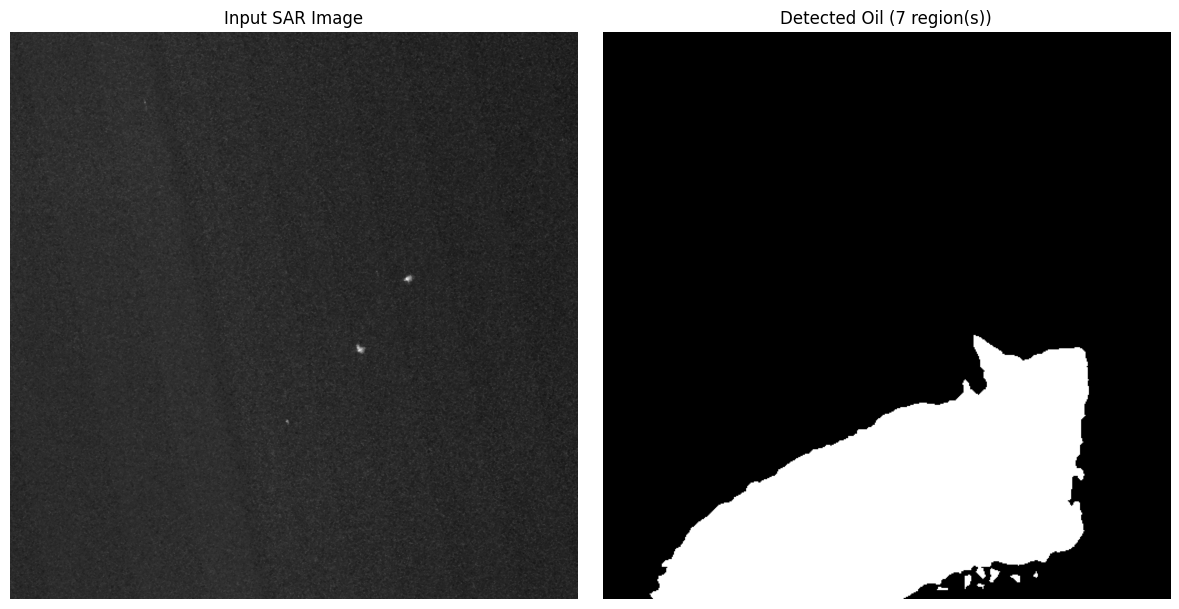


Image: 00077
Detected regions: 7
Total detected area: 0.006904 (in CRS units)
First detection centroid: lat=25.6748, lon=54.6527
Saved to: /kaggle/working/predictions/00077_detection.geojson



/usr/local/lib/python3.12/dist-packages/rasterio/__init__.py:367: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, thread_safe=thread_safe, **kwargs)


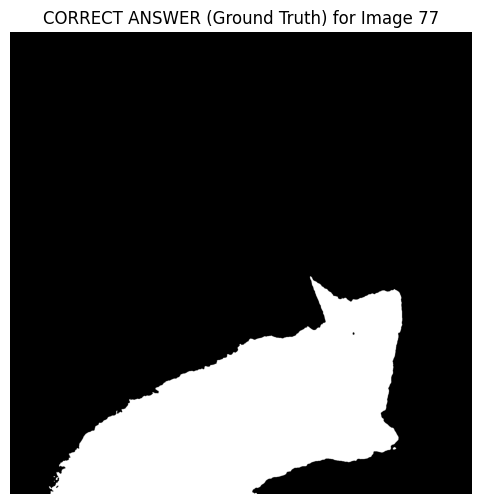

In [15]:
compare_prediction_vs_truth(77)